Importing Dependencies


In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection & Pre-Processing 

In [2]:
# Loading the data from csv file to pandas dataframe 
Car_dataset = pd.read_csv("C:/Users/sampa/OneDrive/Desktop/ML/Car Price Prediction/Car Dataset.csv")

In [3]:
# Analyzing the first 5 rows of dataset
Car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
# Checking the rows and columns 
Car_dataset.shape

(4340, 8)

In [5]:
# Getting info about dataset
Car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
# Checking the number of missing values
Car_dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [7]:
# Checking the disrtibution of categorical data
print(Car_dataset.fuel.value_counts())
print(Car_dataset.transmission.value_counts())
print(Car_dataset.seller_type.value_counts())
print(Car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


Encoding the Categorical Data

In [8]:
 # Encoding fuel
 Car_dataset.replace({'fuel':{'Petrol':0 ,'Diesel':1, 'CNG': 2, 'LPG':3, 'Electric':4}}, inplace=True)

 # Encoding transmission
 Car_dataset.replace({'transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

 # Encoding seller_type
 Car_dataset.replace({'seller_type':{'Individual':0, 'Dealer':1, 'Trustmark Dealer':2}}, inplace=True)

  # Encoding owner
 Car_dataset.replace({'owner':{'First Owner':0, 'Second Owner':1, 'Third Owner':2, 'Fourth & Above Owner':3, 'Test Drive Car':4}}, inplace=True)

C:\Users\sampa\AppData\Local\Temp\ipykernel_7696\2528772412.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Car_dataset.replace({'fuel':{'Petrol':0 ,'Diesel':1, 'CNG': 2, 'LPG':3, 'Electric':4}}, inplace=True)
C:\Users\sampa\AppData\Local\Temp\ipykernel_7696\2528772412.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Car_dataset.replace({'transmission':{'Manual':0, 'Automatic':1}}, inplace=True)
C:\Users\sampa\AppData\Local\Temp\ipykernel_7696\2528772412.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated a

In [9]:
# Analyzing the changes dataset
Car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,0,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,0,0,1


Splitting the data into Target

In [10]:
X = Car_dataset.drop(['name', 'selling_price',], axis=1)
Y = Car_dataset['selling_price']

In [11]:
print(X)

      year  km_driven  fuel  seller_type  transmission  owner
0     2007      70000     0            0             0      0
1     2007      50000     0            0             0      0
2     2012     100000     1            0             0      0
3     2017      46000     0            0             0      0
4     2014     141000     1            0             0      1
...    ...        ...   ...          ...           ...    ...
4335  2014      80000     1            0             0      1
4336  2014      80000     1            0             0      1
4337  2009      83000     0            0             0      1
4338  2016      90000     1            0             0      0
4339  2016      40000     0            0             0      0

[4340 rows x 6 columns]


In [12]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


Splitting the data into Training and Testing data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=3) 

Model Training

1. linear Regression

In [14]:
# Loading the linear regression model
lin_reg_model = LinearRegression()

In [15]:
lin_reg_model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model Evaluation

In [16]:
# Prediction on Training data 
training_data_prediction = lin_reg_model.predict(X_train)

In [17]:
# Squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R Squared Error : ", error_score)

R Squared Error :  0.4381490457384333


Visualize the actual and predicted price

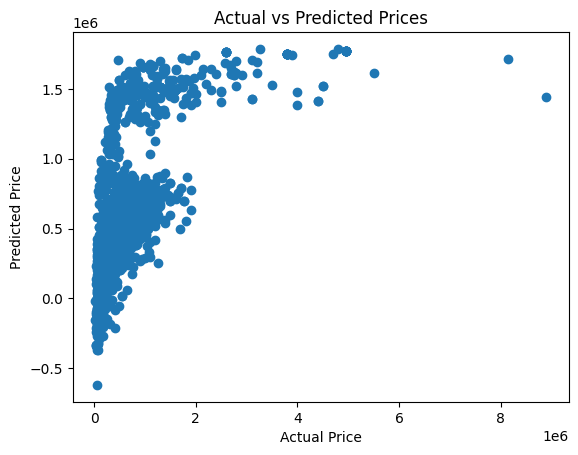

In [18]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [19]:
# Prediction on Training data 
test_data_prediction = lin_reg_model.predict(X_test)

In [20]:
# Squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R Squared Error : ", error_score)

R Squared Error :  0.4441605530081676


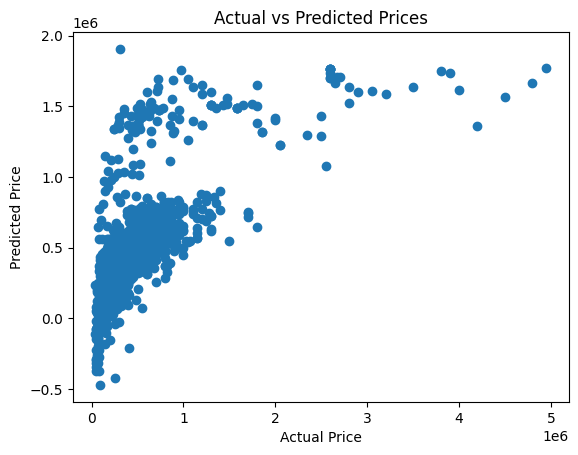

In [21]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

2. Lasso Regression


In [22]:
# Loading the lasso regression model
lass_reg_model = Lasso()

In [23]:
lass_reg_model.fit(X_train, Y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Model Evaluation

In [24]:
# Prediction on Training data 
training_data_prediction = lass_reg_model.predict(X_train)

In [27]:
# Squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R Squared Error : ", error_score)

R Squared Error :  0.43814904568979307


Visualize the actual and predicted price

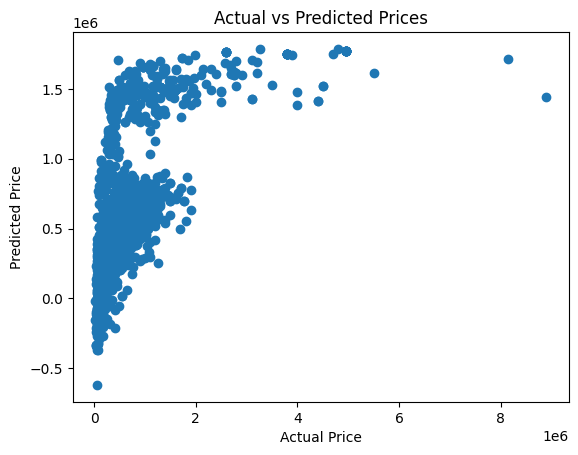

In [26]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [28]:
# Prediction on Training data 
test_data_prediction = lass_reg_model.predict(X_test)

In [29]:
# Squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R Squared Error : ", error_score)

R Squared Error :  0.4441618746991598


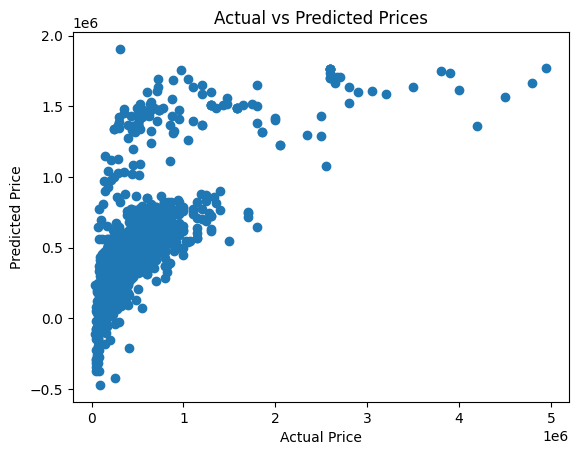

In [30]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()